# Quantum Oracle

#### The quantum oracle Uf acts as |x> |y> --> |x> |y ⊕ f(x)>

#### Consider f(x) = ~x

In [ ]:
import qiskit
from qiskit import QuantumCircuit

In [11]:
qc = QuantumCircuit(2, name='Q_Oracle')
qc.x(1)
qc.cx(1, 0)
qc.x(1)

oracle = qc.to_gate()
oracle.name = "Oracle"

qc_1 = QuantumCircuit(2)
qc_1.h([0, 1])
qc_1.append(oracle, [0, 1])
qc_1.measure_active()

In [12]:
qc_1.draw('mpl')

┌───┐┌─────────┐ ░ ┌─┐   
   q_0: ┤ H ├┤0        ├─░─┤M├───
        ├───┤│  Oracle │ ░ └╥┘┌─┐
   q_1: ┤ H ├┤1        ├─░──╫─┤M├
        └───┘└─────────┘ ░  ║ └╥┘
meas: 2/════════════════════╩══╩═
                            0  1

/usr/local/lib/python3.12/site-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


Simulation Results for qc_1:
{'01': 231, '11': 291, '10': 248, '00': 230}


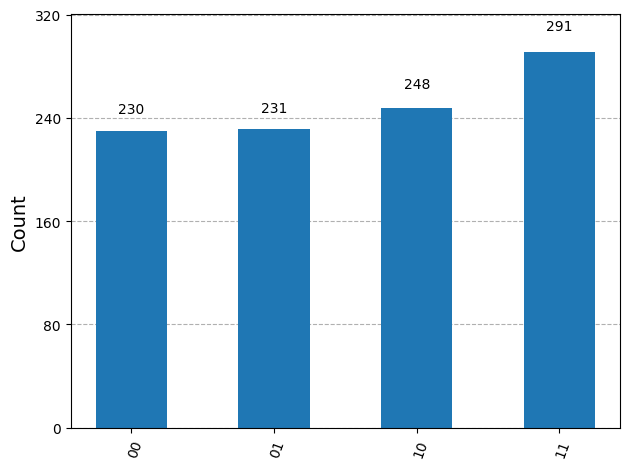

In [13]:
# Simulate qc_1 using AerSimulator and plot the measurement results
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Create simulator
simulator = AerSimulator()

# Transpile for the simulator backend (optional but recommended)
qc_compiled = transpile(qc_1, simulator)

# Run the job
job = simulator.run(qc_compiled, shots=1000)
result = job.result()
counts = result.get_counts()

# Print and plot
print("Simulation Results for qc_1:")
print(counts)

# Display histogram (in a notebook this will render below the cell)
plot_histogram(counts)
